# PS 1: Clustering and Visualization

<center>CLAIM</center>

    I have not used AI assistance in completing this assignment.

<p align="right">signature:______________</p>  
<p align="right">date:______________</p>  

This problem aims to find structure that differentiates European countries based on their food consumption. Dataset protein.csv1 is used.

K-means algorithm is used to cluster this data.

1. Using only 'Red Meat' and 'White Meat' consumption data to compute a K-means cluster

    - First let's import the packages and read in data

In [10]:
# import packages
import numpy as np
import csv

In [11]:
# initialize variables
all_countries = []
X = []
# change dimensions when needed
proteins = ["RedMeat", "WhiteMeat"]

In [12]:
# read in data
with open("protein.csv", "rt", encoding="utf8") as data_file:
    reader = csv.reader(data_file)
    headers = [header.strip() for header in next(reader)]

    dictReader = csv.DictReader(data_file, fieldnames=headers)

    for dRow in dictReader:
        all_countries.append(dRow["Country"])
        X.append([float(dRow[pro]) for pro in proteins])  # limit to defined dimensions

all_countries = np.array(all_countries)
X = np.array(X)  # values in Multidimensional array
N = len(X)  # number of individuals needed to be clustered

K-means algorithm has the following steps:

a) Randomly choose an initial set of points as centers.

Two different methods is shown below for the choosing process. The first method involves randomly sampling from existing data, while the second method involves randomly generating coordinates within the data range.

In [13]:
# initialize centroids
def initialize_centroids_from_existed(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]


def initialize_centroids_in_range(X, k):
    centroids = np.random.rand(k, X.shape[1]) * (
        np.max(X, axis=0) - np.min(X, axis=0)
    ) + np.min(X, axis=0)
    return centroids

b) For each center, identify the subset of training points that is closer to it than any 
other center.  

In [14]:
# allocate to the nearest center
def closest_centroid(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels

c) Calculate the means of each feature for the data points in each cluster. This 
mean vector is the new cluster center.  

In [15]:
# update the cluster center
def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])


d) Repeat steps (b) and (c) many times until each center stabilizes. 

Two different ways to determine convergence are presented in the following code. Sum of Squared Errors (SSE) is used in this example as the loss function.

In [24]:
# break condition
def centroids_move(new_centroids, centroids, tol=1e-4):
    if np.all(np.abs(new_centroids - centroids) < tol):
        return True
    else:
        return False


def SSE(X, labels, centroids):
    sse = 0
    for k in range(len(centroids)):
        points_in_k = X[labels == k]
        cluster_loss = np.sum((points_in_k - centroids[k]) ** 2)
        sse += cluster_loss
    return sse


In [68]:
def kmeans(X, k, max_iters, tol):
    centroids = initialize_centroids_in_range(X, k)
    loss_previous = np.inf
    for i in range(max_iters):
        labels = closest_centroid(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        loss = SSE(X, labels, centroids)
        if np.abs(loss_previous - loss) < tol:
            print(f"The algorithm with K value {k} converged in iteration {i} ")
            break
        centroids = new_centroids
        loss_previous = loss
    return labels, centroids, loss

In [35]:
# set K value
labels, centroids, loss = kmeans(X, k=3, max_iters=100, tol=0.1)
print("Final Cluster:", labels)
print("Centroids Positions:", centroids)
print("Loss", loss)

The algorithm converged in iteration 5 
Final Cluster: [0 2 1 0 2 2 2 0 1 0 2 1 0 2 0 2 0 0 0 0 1 1 0 2 0]
Centroids Positions: [[ 8.25833333  4.65833333]
 [15.18        9.        ]
 [ 8.8375     12.0625    ]]
Loss 144.9838333333333


- K is fixed at 3

    - Why do we need to repeat steps (b) and (c)? What happens if we just do steps (a)-(c) once? 

    The reason for repetition is that K-means is an iterative optimization process. A single calculation usually cannot directly find the optimal solution. Through repeated assignment and updating, the centroids gradually move towards the dense core of the data until a stable state is reached.

    If we only did it once, the result would be highly dependent on the quality of the initial random points. The centroids might remain in random positions far from the data center, leading to very poor and inaccurate clustering results that do not truly reflect the data structure.

In [104]:
def best_overall_loss(X, n, k, max_iters, tol):
    best_overall_loss = np.inf
    best_labels = None
    best_centroids = None

    for i in range(n):
        labels, centroids, loss = kmeans(X, k, max_iters, tol)
        if loss < best_overall_loss:
            best_overall_loss = loss
            best_labels = labels
            best_centroids = centroids

    return best_labels, best_centroids, best_overall_loss

In [105]:
labels, centroids, loss = best_overall_loss(X, n=5, k=3, max_iters=100, tol=0.1)

print("Final Cluster:", labels)
print("Centroids Positions:", centroids)
print("Loss", loss)

The algorithm with K value 3 converged in iteration 4 
The algorithm with K value 3 converged in iteration 4 
The algorithm with K value 3 converged in iteration 4 
The algorithm with K value 3 converged in iteration 4 
The algorithm with K value 3 converged in iteration 5 
Final Cluster: [1 2 0 1 2 2 2 1 0 1 2 0 1 2 1 2 1 1 1 1 0 0 1 2 1]
Centroids Positions: [[15.18        9.        ]
 [ 8.25833333  4.65833333]
 [ 8.8375     12.0625    ]]
Loss 144.9838333333333


- K is fixed at 3
    - What happens to the resulting clusters if you draw different initial center points?   
        
    Because some draws will lead to better partitions than others, I repeat the entire algorithm several times starting from several random draws of initial center points. 
        
    For the final solution, the partition that minimizes the within cluster point scatter is: 
    
    "Final Cluster: [0 1 2 0 1 1 1 0 2 0 1 2 0 1 0 1 0 0 0 0 2 2 0 1 0]
    
    Centroids Positions: [[ 8.25833333  4.65833333]
    [ 8.8375     12.0625    ]
     [15.18        9.        ]]
    
    Loss 144.9838333333333"

Next, K is set at 1 to 10.

In [106]:
%%capture

k_values = range(1, 11)
losses = []

for k in k_values:
    labels, centroids, loss = best_overall_loss(X, n=20, k=k, max_iters=200, tol=0.05)
    losses.append(loss)

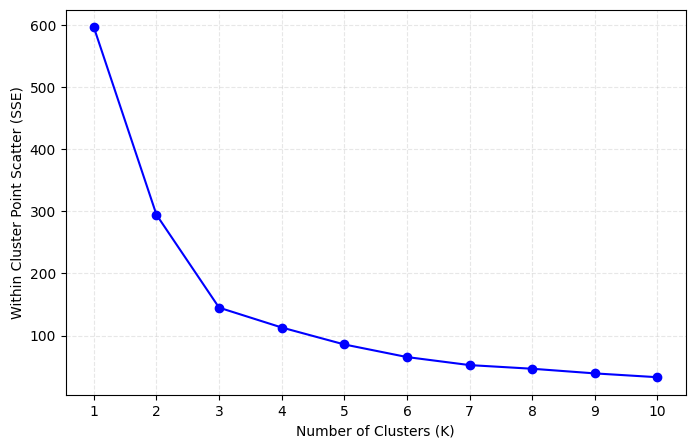

In [ ]:
# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, losses, "bo-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Point Scatter (SSE)")
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [111]:
# visualize k=3
labels, centroids, loss = best_overall_loss(X, n=5, k=3, max_iters=100, tol=0.1)

The algorithm with K value 3 converged in iteration 6 
The algorithm with K value 3 converged in iteration 3 
The algorithm with K value 3 converged in iteration 4 
The algorithm with K value 3 converged in iteration 5 
The algorithm with K value 3 converged in iteration 4 


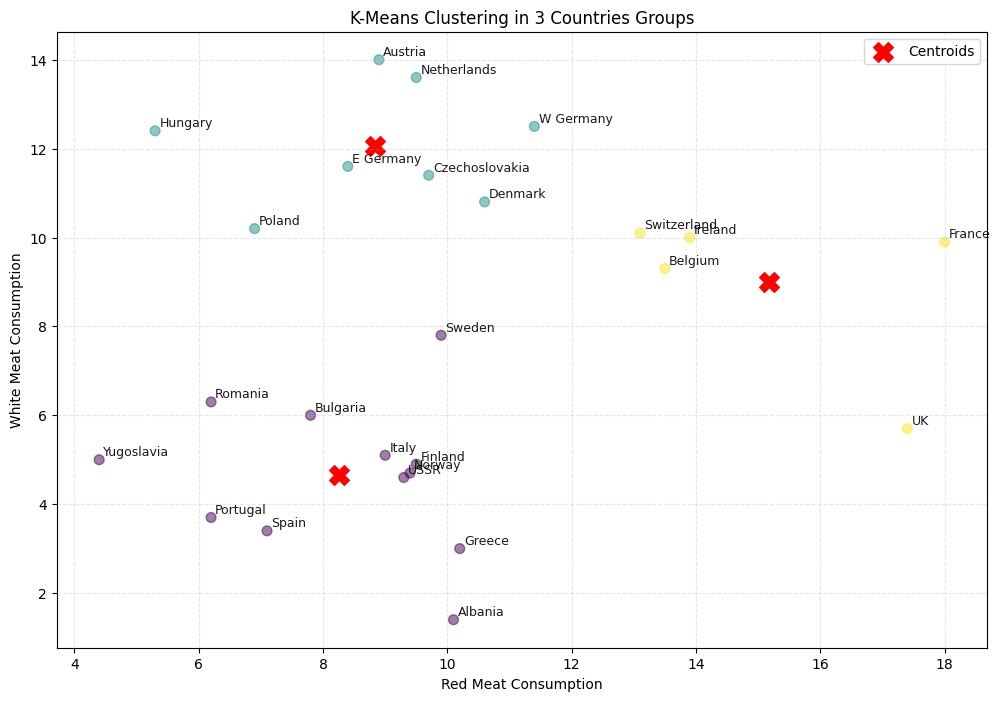

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=50, alpha=0.5)

for i, txt in enumerate(all_countries):
    plt.annotate(
        txt,
        (X[i, 0], X[i, 1]),
        fontsize=9,
        alpha=0.9,
        xytext=(3, 3),
        textcoords="offset points",
    )

plt.scatter(
    centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200, label="Centroids"
)

plt.xlabel("Red Meat Consumption")
plt.ylabel("White Meat Consumption")
plt.title("K-Means Clustering in 3 Countries Groups")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

- Graph how the within cluster point scatter varies as K increases from K=1 
to K=10. 

    - Should the within cluster point scatter ever increase as you add another cluster? 

    No. As K increases, the number of centroids increases, and the distance of each data point to its nearest centroid will theoretically only decrease or remain the same. When K equals the total number of samples N, each point itself becomes a centroid, and the SSE will drop to 0. Therefore, the SSE curve should be monotonically decreasing.
    
    - If you observe an unexpected pattern as you increase k: What could be causing this? 
Can you adjust your code to avoid it? 

    I observe the empty cluster. I increase the repeating number for every K to avoid it.
    
    I also observe that sometimes the SSE when K=9 is unexpectedly lower than that in K=10. It might because of Local Optima. I increase the repeating number for every K, lower the tolerance loss difference, increase max iterations to avoid it.

    - What is your preferred number of clusters? 
    
    My preferred number is 3 as using the Elbow Method.

    - What countries are in which clusters? 

    See the graph K-Means Clustering in 3 Countries Groups.
    
    - How does the algorithm’s result compare to how you would have classified the countries visually, based on the plot? 

    Almost as the same as what I expected. Visually, although France and UK are classified into the same category by the algorithm, their position on the graph is very different.
    

2. Extend my analysis to use Red Meat, White Meat, Eggs, and Milk consumption

    Based on an initial observation of the four protein dimensions, the countries appear to cluster naturally into three distinct dietary patterns. The first group consists of high-protein Western nations like France and the UK, which exhibit exceptionally high red meat consumption alongside stable intake of eggs and milk. A second group is defined by a specific Nordic profile, where countries like Finland and Denmark stand out due to their massive milk consumption, even if their meat intake is only moderate. Finally, a third group includes Eastern European and Balkan nations such as Albania and Bulgaria, characterized by significantly lower values across all four animal protein categories. 

In [113]:
# initialize variables
all_countries = []
X = []
# change dimensions
proteins = ["RedMeat", "WhiteMeat", "Eggs", "Milk"]

In [114]:
# read in data
with open("protein.csv", "rt", encoding="utf8") as data_file:
    reader = csv.reader(data_file)
    headers = [header.strip() for header in next(reader)]

    dictReader = csv.DictReader(data_file, fieldnames=headers)

    for dRow in dictReader:
        all_countries.append(dRow["Country"])
        X.append([float(dRow[pro]) for pro in proteins])  # limit to defined dimensions

all_countries = np.array(all_countries)
X = np.array(X)  # values in Multidimensional array
N = len(X)  # number of individuals needed to be clustered

In [121]:
labels, centroids, loss = best_overall_loss(X, n=5, k=3, max_iters=100, tol=0.1)

print("Final Cluster:", labels)
print("Centroids Positions:", centroids)
print("Loss", loss)

The algorithm with K value 3 converged in iteration 4 
The algorithm with K value 3 converged in iteration 3 
The algorithm with K value 3 converged in iteration 3 
The algorithm with K value 3 converged in iteration 3 
The algorithm with K value 3 converged in iteration 6 
Final Cluster: [1 0 0 1 1 0 1 2 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1 0 1]
Centroids Positions: [[11.74615385  9.35384615  3.63846154 21.47692308]
 [ 7.59090909  6.44545455  2.12727273 10.44545455]
 [ 9.5         4.9         2.7        33.7       ]]
Loss 649.9239160839161


In [128]:
%%capture

k_values = range(1, 11)
losses = []

for k in k_values:
    labels, centroids, loss = best_overall_loss(X, n=50, k=k, max_iters=300, tol=0.05)
    losses.append(loss)

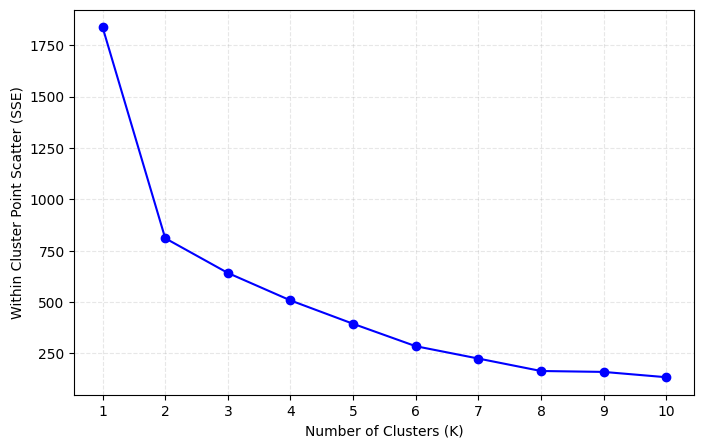

In [129]:
# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, losses, "bo-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within Cluster Point Scatter (SSE)")
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

K-means clusters of the data is computed as above. The within cluster point scatter decreases as K increases.

My preferred number is 2 as using the Elbow Method.

In [ ]:
%%capture
# k=2

k = 2
labels, centroids, loss = best_overall_loss(X, n=50, k=k, max_iters=300, tol=0.05)

In [137]:
# print result
print(f"--- K-Means clustering result (K={k}) ---")


for cluster_id in range(k):
    countries_in_this_cluster = all_countries[labels == cluster_id]

    print(f"\nGroup {cluster_id + 1}:")
    print(", ".join(countries_in_this_cluster))

--- K-Means clustering result (K=2) ---

Group 1:
Austria, Belgium, Denmark, Finland, France, Ireland, Netherlands, Norway, Poland, Sweden, Switzerland, UK, W Germany

Group 2:
Albania, Bulgaria, Czechoslovakia, E Germany, Greece, Hungary, Italy, Portugal, Romania, Spain, USSR, Yugoslavia


- How does the algorithm’s result compare to the clusters you created on your own?
    
    - The algorithm successfully captured the broad divide I anticipated between high-consumption and the lower-consumption countries. However, it simplified my initial three-group intuition into a binary split, merging the 'High-Dairy' and 'High-Meat' groups into a single cluster based on their shared high intake levels compared to the rest of the dataset.